# Rafael TCC - Projeto 04
## Análise Multivariada Pareada: DEPs × Selos Comerciais
Avaliação do confronto entre características genéticas (DEPs/TOPs) e a chancela de mercado (Selos Comerciais CRV) na precificação do sêmen Nelore (ANCP).


### Bibliotecas

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


### Carga e Integração dos Dados (DEPs + Linhagens)

In [2]:
# 1. Carregar base de touros ANCP válidos (N = 115)
df_ancp = pd.read_csv('Dados/CSV/NeloreCRV_ANCP_valido.csv')

# 2. Carregar dados gerais contendo a genealogia e criador
df_geral = pd.read_csv('Dados/CSV/NeloreCRV_Dados_Gerais.csv')
cols_genealogia = ['crv_code', 'criador', 'proprietario', 'linhagem', 'pai', 'avo_paterno', 'avo_materno']

df_dl = pd.merge(
    df_ancp, 
    df_geral[cols_genealogia], 
    left_on='CRV_COD', 
    right_on='crv_code', 
    how='inner'
)

# 3. Engenharia de Dummies dos Troncos Genéticos / Linhagens
troncos = {
    'TRONCO_EAO': lambda r: 1 if any('EAO' in str(x).upper() for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME'], r['criador']]) else 0,
    'TRONCO_REM': lambda r: 1 if any('REM' in str(x).upper() for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_NAVIRAI': lambda r: 1 if any(('NAVIRAI' in str(x).upper() or 'NAVIRAÍ' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_COLONIAL': lambda r: 1 if any(('COL' in str(x).upper() or 'COLONIAL' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_MATINHA': lambda r: 1 if any(('MAT' in str(x).upper() or 'MATINHA' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_LEMGRUBER_MN': lambda r: 1 if any((' MN' in str(x).upper() or 'MUNDO NOVO' in str(x).upper() or 'LEMGRUBER' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0,
    'TRONCO_IZ': lambda r: 1 if any(('IZ' in str(x).upper() or 'SERTÃOZINHO' in str(x).upper()) for x in [r['linhagem'], r['pai'], r['avo_paterno'], r['avo_materno'], r['NOME']]) else 0
}

for nome, func in troncos.items():
    df_dl[nome] = df_dl.apply(func, axis=1)

# Dicionário de DEPs (18 características)
deps_dict = {
    'MGTe_TOP': 'MGTe (Geral)',
    'P210_TOP': 'P210 (Desmama)',
    'P365_TOP': 'P365 (Ano)',
    'P450_TOP': 'P450 (Sobreano)',
    'FRAME_TOP': 'FRAME (Frame)',
    'PAC_TOP': 'PAC (Peso Vaca)',
    '3P_TOP': '3P (Precocidade)',
    'IPP_TOP': 'IPP (Idade 1º Parto)',
    'STAY_TOP': 'STAY (Longevidade)',
    'PE450_TOP': 'PE450 (Perímetro Escrotal)',
    'MP120_TOP': 'MP120 (Maternal 120d)',
    'MP210_TOP': 'MP210 (Maternal 210d)',
    'PN_TOP': 'PN (Peso Nascer)',
    'FPP_TOP': 'FPP (Facilidade Parto)',
    'AOL_TOP': 'AOL (Musculatura)',
    'ACAB_TOP': 'ACAB (Acabamento)',
    'MARM_TOP': 'MARM (Marmoreio)',
    'CAR_TOP': 'CAR (Consumo Residual)'
}

cols_deps = [c for c in deps_dict.keys() if c in df_dl.columns]
cols_linhagens = list(troncos.keys())

print("=" * 80)
print(f"BASE PREPARADA COM SUCESSO: N = {len(df_dl)} touros")
print(f"Total de DEPs: {len(cols_deps)} | Total de Linhagens: {len(cols_linhagens)}")
print("=" * 80)

BASE PREPARADA COM SUCESSO: N = 115 touros
Total de DEPs: 18 | Total de Linhagens: 7


###  Random Forest Amplo (Duelo DEPs vs. Linhagens)

RANKING RANDOM FOREST: DUELO DEPs × LINHAGENS


,Atributo,Tipo,Nome_Exibicao,Importância (%),Acumulado (%)
0,CAR_TOP,DEP,CAR (Consumo Residual),12.07,12.07
1,3P_TOP,DEP,3P (Precocidade),9.05,21.12
2,MP210_TOP,DEP,MP210 (Maternal 210d),6.09,27.21
3,MP120_TOP,DEP,MP120 (Maternal 120d),5.77,32.98
4,PN_TOP,DEP,PN (Peso Nascer),5.33,38.31
5,AOL_TOP,DEP,AOL (Musculatura),5.10,43.41
6,FPP_TOP,DEP,FPP (Facilidade Parto),5.09,48.50
7,STAY_TOP,DEP,STAY (Longevidade),4.86,53.36
8,PE450_TOP,DEP,PE450 (Perímetro Escrotal),4.59,57.95
9,PAC_TOP,DEP,PAC (Peso Vaca),4.49,62.44


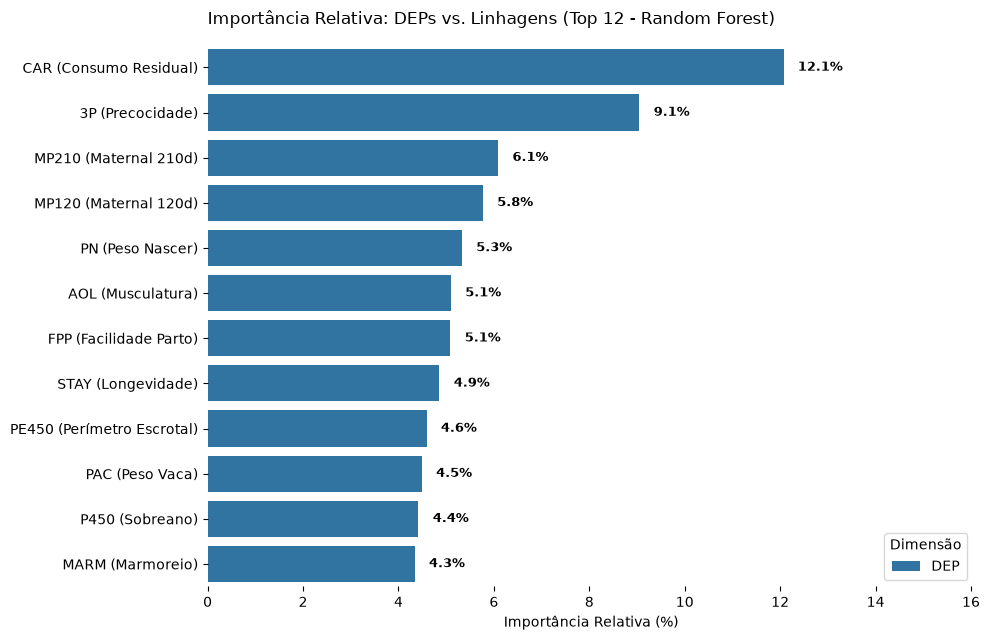

In [3]:
# 1. Preparação das features para o duelo
features_duelo = cols_deps + cols_linhagens
X_rf = df_dl[features_duelo].copy()
y = df_dl['SEMEM'].copy()

# Tratar pontuais NaNs nas DEPs com a mediana
X_rf = X_rf.fillna(X_rf.median())

# 2. Ajuste do Random Forest (500 árvores)
rf = RandomForestRegressor(n_estimators=500, random_state=42, max_features='sqrt')
rf.fit(X_rf, y)

# 3. Tabela de Importâncias
df_imp_duelo = pd.DataFrame({
    'Atributo': features_duelo,
    'Tipo': ['DEP' if c in cols_deps else 'Linhagem' for c in features_duelo],
    'Nome_Exibicao': [deps_dict.get(c, c.replace('TRONCO_', 'Linhagem ')) for c in features_duelo],
    'Importância (%)': (rf.feature_importances_ * 100).round(2)
}).sort_values(by='Importância (%)', ascending=False).reset_index(drop=True)

df_imp_duelo['Acumulado (%)'] = df_imp_duelo['Importância (%)'].cumsum().round(2)

print("=" * 80)
print("RANKING RANDOM FOREST: DUELO DEPs × LINHAGENS")
print("=" * 80)
display(df_imp_duelo.head(12))

# 4. Gráfico de Barras Colorido por Dimensão (Azul = DEP, Roxo = Linhagem)
plt.figure(figsize=(10, 6.5))
palette = {'DEP': '#1f77b4', 'Linhagem': '#9467bd'}

ax = sns.barplot(
    data=df_imp_duelo.head(12),
    x='Importância (%)',
    y='Nome_Exibicao',
    hue='Tipo',
    dodge=False,
    palette=palette
)

for p, val in zip(ax.patches, df_imp_duelo.head(12)['Importância (%)']):
    ax.text(val + 0.3, p.get_y() + p.get_height() / 2, f"{val:.1f}%", va='center', fontsize=9, fontweight='bold')

ax.set_title('Importância Relativa: DEPs vs. Linhagens (Top 12 - Random Forest)', fontsize=12, loc='left', pad=15)
ax.set_xlabel('Importância Relativa (%)', fontsize=10)
ax.set_ylabel('')
ax.set_xlim(0, df_imp_duelo['Importância (%)'].max() + 4)
ax.legend(title='Dimensão', loc='lower right', frameon=True)
sns.despine(left=True, bottom=True, top=True, right=True)
plt.tight_layout()
plt.show()

### Regressão OLS Pareada (DEPs × Linhagens)

In [4]:
# OLS 1: Apenas a melhor DEP (CAR_TOP)
X_m1 = sm.add_constant(df_dl[['CAR_TOP']].fillna(df_dl['CAR_TOP'].median()))
m_deps = sm.OLS(y, X_m1).fit()

# OLS 2: Apenas a Linhagem Significativa (TRONCO_EAO)
X_m2 = sm.add_constant(df_dl[['TRONCO_EAO']])
m_linhagem = sm.OLS(y, X_m2).fit()

# OLS 3: Modelo Conjunto Pareado (CAR_TOP + TRONCO_EAO)
X_m3 = sm.add_constant(df_dl[['CAR_TOP', 'TRONCO_EAO']].fillna({'CAR_TOP': df_dl['CAR_TOP'].median()}))
m_conjunto = sm.OLS(y, X_m3).fit()

# Tabela comparativa do Duelo
tabela_duelo = pd.DataFrame([
    {
        'Modelo': '1. Apenas Genética (CAR_TOP)',
        'R² (%)': f"{m_deps.rsquared * 100:.1f}%",
        'R² Ajustado (%)': f"{m_deps.rsquared_adj * 100:.1f}%",
        'p-valor': f"{m_deps.f_pvalue:.4e}",
        'AIC': f"{m_deps.aic:.1f}"
    },
    {
        'Modelo': '2. Apenas Linhagem (TRONCO_EAO)',
        'R² (%)': f"{m_linhagem.rsquared * 100:.1f}%",
        'R² Ajustado (%)': f"{m_linhagem.rsquared_adj * 100:.1f}%",
        'p-valor': f"{m_linhagem.f_pvalue:.4e}",
        'AIC': f"{m_linhagem.aic:.1f}"
    },
    {
        'Modelo': '3. Duelo Pareado (DEPs × Linhagem)',
        'R² (%)': f"{m_conjunto.rsquared * 100:.1f}%",
        'R² Ajustado (%)': f"{m_conjunto.rsquared_adj * 100:.1f}%",
        'p-valor': f"{m_conjunto.f_pvalue:.4e}",
        'AIC': f"{m_conjunto.aic:.1f}"
    }
])

print("=" * 90)
print("COMPARAÇÃO ECONOMÉTRICA: DEPs ISOLADAS vs. LINHAGEM ISOLADA vs. CONJUNTO")
print("=" * 90)
display(tabela_duelo)

print("\n" + "=" * 90)
print("SUMÁRIO DO MODELO PAREADO: DEPs × LINHAGEM")
print("=" * 90)
print(m_conjunto.summary())

COMPARAÇÃO ECONOMÉTRICA: DEPs ISOLADAS vs. LINHAGEM ISOLADA vs. CONJUNTO


,Modelo,R² (%),R² Ajustado (%),p-valor,AIC
0,1. Apenas Genética (CAR_TOP),6.5%,5.7%,5.9570e-03,762.1
1,2. Apenas Linhagem (TRONCO_EAO),7.5%,6.6%,3.1378e-03,760.9
2,3. Duelo Pareado (DEPs × Linhagem),12.5%,10.9%,5.8197e-04,756.5



SUMÁRIO DO MODELO PAREADO: DEPs × LINHAGEM
                            OLS Regression Results                            
Dep. Variable:                  SEMEM   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.109
Method:                 Least Squares   F-statistic:                     7.967
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           0.000582
Time:                        23:57:01   Log-Likelihood:                -375.26
No. Observations:                 115   AIC:                             756.5
Df Residuals:                     112   BIC:                             764.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const   

### Gráfico de Barras Divergentes dos Coeficientes $\beta$ (DEPs × Linhagens)

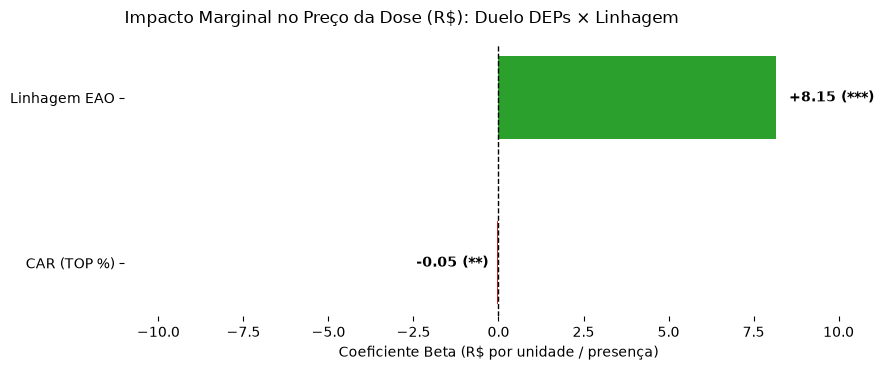

In [5]:
# Extrair coeficientes e p-valores do modelo pareado
coef_data = pd.DataFrame({
    'Variável': ['Linhagem EAO', 'CAR (TOP %)'],
    'Beta': [m_conjunto.params['TRONCO_EAO'], m_conjunto.params['CAR_TOP']],
    'p_valor': [m_conjunto.pvalues['TRONCO_EAO'], m_conjunto.pvalues['CAR_TOP']]
}).sort_values(by='Beta', ascending=True).reset_index(drop=True)

cores = ['#2ca02c' if b > 0 else '#d62728' for b in coef_data['Beta']]

plt.figure(figsize=(9, 3.8))
ax = plt.subplot(111)
barras = ax.barh(coef_data['Variável'], coef_data['Beta'], color=cores, height=0.5, edgecolor='none')

ax.axvline(0, color='black', linewidth=1, linestyle='--')

for bar, beta, p in zip(barras, coef_data['Beta'], coef_data['p_valor']):
    sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else 'ns'))
    texto = f" {beta:+.2f} ({sig})"
    if beta >= 0:
        ax.text(beta + 0.25, bar.get_y() + bar.get_height()/2, texto, va='center', ha='left', fontsize=10, fontweight='bold')
    else:
        ax.text(beta - 0.25, bar.get_y() + bar.get_height()/2, texto, va='center', ha='right', fontsize=10, fontweight='bold')

limite = max(abs(coef_data['Beta'])) * 1.35
ax.set_xlim(-limite, limite)
ax.set_title('Impacto Marginal no Preço da Dose (R$): Duelo DEPs × Linhagem', fontsize=12, loc='left', pad=15)
ax.set_xlabel('Coeficiente Beta (R$ por unidade / presença)', fontsize=10)
sns.despine(left=True, bottom=True, top=True, right=True)
plt.tight_layout()
plt.show()